In [1]:
!pip install numpy pandas scikit-fuzzy matplotlib requests
import numpy as np
import pandas as pd
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
%matplotlib inline

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 11.4 MB/s eta 0:00:00


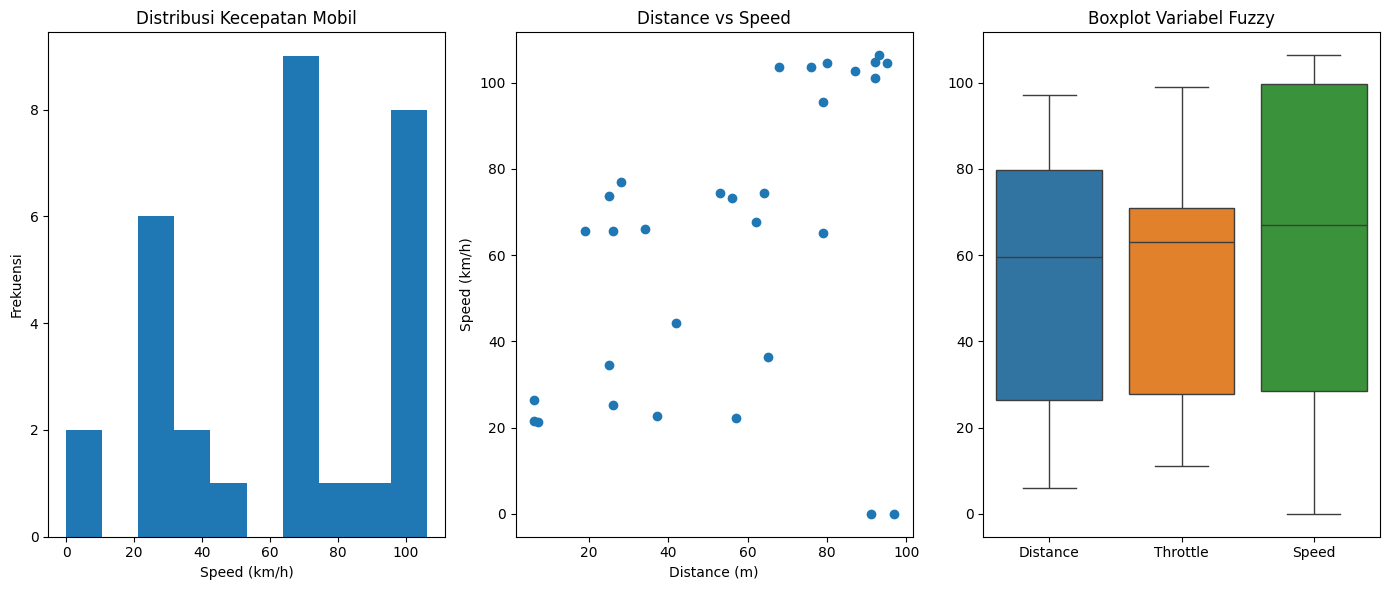

=== Dataset Awal (3 Kolom) ===
   Distance  Throttle   Speed
0        56        68   73.16
1        97        51    0.00
2        19        69   65.54
3        76        89  103.67
4        65        24   36.34 

=== Dataset Akhir (5 Kolom) ===
   Distance  Throttle   Speed  GapRatio  Efficiency
0        56        68   73.16      1.21        1.08
1        97        51    0.00      0.53        0.00
2        19        69   65.54      3.63        0.95
3        76        89  103.67      1.17        1.16
4        65        24   36.34      0.37        1.51 

File CSV berhasil dibuat: speed_fuzzy_raw.csv & speed_fuzzy_final.csv


In [7]:
import numpy as np
import pandas as pd
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
import seaborn as sns

distance = ctrl.Antecedent(np.arange(0, 101, 1), 'distance')
throttle = ctrl.Antecedent(np.arange(0, 101, 1), 'throttle')
speed = ctrl.Consequent(np.arange(0, 121, 1), 'speed')

distance['close'] = fuzz.trimf(distance.universe, [0, 0, 40])
distance['medium'] = fuzz.trimf(distance.universe, [20, 50, 80])
distance['far'] = fuzz.trimf(distance.universe, [60, 100, 100])

throttle['low'] = fuzz.trimf(throttle.universe, [0, 0, 40])
throttle['medium'] = fuzz.trimf(throttle.universe, [20, 50, 80])
throttle['high'] = fuzz.trimf(throttle.universe, [60, 100, 100])

speed['slow'] = fuzz.trimf(speed.universe, [0, 0, 60])
speed['medium'] = fuzz.trimf(speed.universe, [30, 70, 100])
speed['fast'] = fuzz.trimf(speed.universe, [80, 120, 120])

rule1 = ctrl.Rule(distance['close'] & throttle['high'], speed['medium'])
rule2 = ctrl.Rule(distance['close'] & throttle['low'], speed['slow'])
rule3 = ctrl.Rule(distance['medium'] & throttle['medium'], speed['medium'])
rule4 = ctrl.Rule(distance['far'] & throttle['high'], speed['fast'])
rule5 = ctrl.Rule(distance['far'] & throttle['low'], speed['medium'])
rule6 = ctrl.Rule(distance['medium'] & throttle['high'], speed['fast'])
rule7 = ctrl.Rule(distance['medium'] & throttle['low'], speed['slow'])

speed_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7])
speed_sim = ctrl.ControlSystemSimulation(speed_ctrl)

np.random.seed(42)
data_size = 30
distance_data = np.random.randint(5, 100, data_size)
throttle_data = np.random.randint(10, 100, data_size)

speed_result = []

for d, t in zip(distance_data, throttle_data):

    d = np.clip(d, 0, 100)
    t = np.clip(t, 0, 100)

    speed_sim.input['distance'] = d
    speed_sim.input['throttle'] = t
    speed_sim.compute()


    s = speed_sim.output.get('speed', np.nan)
    speed_result.append(s)


    speed_sim.reset()


speed_result = np.nan_to_num(speed_result, nan=0.0)


df_raw = pd.DataFrame({
    'Distance': distance_data,
    'Throttle': throttle_data,
    'Speed': np.round(speed_result, 2)
})

df_raw['GapRatio'] = np.round(df_raw['Throttle'] / df_raw['Distance'], 2)
df_raw['Efficiency'] = np.round(df_raw['Speed'] / df_raw['Throttle'], 2)


df_raw[['Distance', 'Throttle', 'Speed']].to_csv('speed_fuzzy_raw.csv', index=False)
df_raw.to_csv('speed_fuzzy_final.csv', index=False)


plt.figure(figsize=(14, 6))

plt.subplot(1, 3, 1)
plt.hist(df_raw['Speed'], bins=10)
plt.title('Distribusi Kecepatan Mobil')
plt.xlabel('Speed (km/h)')
plt.ylabel('Frekuensi')

plt.subplot(1, 3, 2)
plt.scatter(df_raw['Distance'], df_raw['Speed'])
plt.title('Distance vs Speed')
plt.xlabel('Distance (m)')
plt.ylabel('Speed (km/h)')

plt.subplot(1, 3, 3)
sns.boxplot(df_raw[['Distance', 'Throttle', 'Speed']])
plt.title('Boxplot Variabel Fuzzy')

plt.tight_layout()
plt.savefig('speed_fuzzy_visuals.png')
plt.show()

# ------------------------------------------------------
# 9. Output ringkas
# ------------------------------------------------------
print("=== Dataset Awal (3 Kolom) ===")
print(df_raw[['Distance', 'Throttle', 'Speed']].head(), "\n")

print("=== Dataset Akhir (5 Kolom) ===")
print(df_raw.head(), "\n")

print("File CSV berhasil dibuat: speed_fuzzy_raw.csv & speed_fuzzy_final.csv")
